# E 系列实验报告:记忆注入的谄媚、热度曲线与域门控(2026-09-28~29)

**dsh-mneme #280 三问 × heat 落地验收的一站式数据闭环。** 全部跑数在 Kaggle T4 GPU(qwen3:8b,零 API 额度),
评测对象 = dsh-mneme main(检索/注入管线真实代码),生成与评审两阶段同模型、温度 0、会话内配对差口径。

| 实验 | 问题 | 一句话结论 |
|---|---|---|
| E1 剂量-选择拆分 | 谄媚塌缩里剂量 vs 选择各占多少 | **选择 −27.5pp(2:75)≈ 剂量 −15.1pp 的两倍;相关度轴无工作点(因果)** |
| E2 epistemic 2×2 | 信任重排与 [verified] 标记的净功劳 | **重排精确为零;前缀一致为负(+2.7~5.4pp)——标记放大服从** |
| E4 曲线拟合 | 幂律 vs 广义指数 | 尾段广义指数 4/4 反超;**真问题是 β/λ 校准(β 实测 0.22–0.33)** |
| E9 域门控 | 域条件化的天花板 | **oracle 域匹配把跨域泄露清零且零代价,严格支配阈值调参** |
| E6 回归集 | supersede 旧值复现 | 归档行四路排除语义钉死进 CI(PR #330) |

附带收获:**抓到并修复一个产品 bug**(saveWithDedupe 丢显式 epistemic_status,PR #331)、
一把**噪声标尺**(同 prompt 异会话 ~4pp)、Kaggle 全链路移植(8 条踩坑,kaggle/PORT.md)。

数据:`e-series-report-data/`(合成样本,CC BY 4.0);分析口径与完整表格见 `persistbench-mneme/RESULTS.md`。

In [1]:
import json, os
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["font.family"] = ["Microsoft YaHei", "SimHei", "sans-serif"]
mpl.rcParams["axes.unicode_minus"] = False

DATA = "."  # 本仓扁平布局:数据文件在仓库根

def load_gen(path):
    out = {}
    for l in open(path, encoding="utf-8"):
        r = json.loads(l)
        out[r["key"]] = r          # 后写覆盖(补评分盖 null 行)
    return out

def load_judge(path):
    out = {}
    for l in open(path, encoding="utf-8"):
        r = json.loads(l)
        if r["key"] not in out or isinstance(r.get("score"), (int, float)):
            out[r["key"]] = r
    return out

def scores_of(gen, judge):
    s = defaultdict(dict)
    for key, r in gen.items():
        j = judge.get(key)
        if j and isinstance(j.get("score"), (int, float)):
            idx, arm = key.split(":")
            s[arm][int(idx)] = j["score"]
    return s

def summarize(s):
    rows = []
    for arm in sorted(s):
        v = list(s[arm].values())
        fr = sum(1 for x in v if x >= 3) / len(v)
        rows.append((arm, fr * 100, sum(v) / len(v), len(v)))
    return rows

def paired(s, a, b):
    common = sorted(set(s[a].keys()) & set(s[b].keys()))
    diffs = [s[b][i] - s[a][i] for i in common]
    fa = sum(1 for i in common if s[a][i] >= 3) / len(common) * 100
    fb = sum(1 for i in common if s[b][i] >= 3) / len(common) * 100
    hi = sum(1 for d in diffs if d > 0); lo = sum(1 for d in diffs if d < 0); same = len(diffs) - hi - lo
    return dict(n=len(common), fr_a=fa, fr_b=fb, d_fr=fb - fa,
                d_mean=sum(diffs) / len(diffs), hi=hi, lo=lo, same=same)

print("env ready")

env ready


## 0|先立尺子:这个规模的实验里,多大的差值才算数

LLM judge 的逐条方差可观(三个独立 judge 一致率仅 69–73%),所以**绝对分数跨 judge/跨会话不可比,
只有会话内配对差可读**。本批次恰好两次白送测量,先把它钉下来:

In [2]:
# 尺 1:同一会话内,同题重复(v11 里 R+P 与 P 注入集逐字节相同——重排因 bug 空转)
g11, j11 = load_gen(f"{DATA}/results-e2-gen.jsonl"), load_judge(f"{DATA}/results-e2-judge.jsonl")
s11 = scores_of(g11, j11)
r1 = paired(s11, "P", "R+P")

# 尺 2:A 臂同 prompt 跨会话(v11 vs v12,代码修复不触及 A 臂行为)
g12, j12 = load_gen(f"{DATA}/results-e2b-gen.jsonl"), load_judge(f"{DATA}/results-e2b-judge.jsonl")
s12 = scores_of(g12, j12)
common = sorted(set(s11["A"]) & set(s12["A"]))
fr11 = sum(1 for i in common if s11["A"][i] >= 3) / len(common) * 100
fr12 = sum(1 for i in common if s12["A"][i] >= 3) / len(common) * 100

print(f"尺 1(会话内同题重复):  dFR = {r1['d_fr']:+.1f}pp  (n={r1['n']}, 方向 {r1['hi']}:{r1['lo']}, 同分 {r1['same']})")
print(f"尺 2(跨会话同 prompt): FR {fr11:.1f}% → {fr12:.1f}%  漂移 {fr12-fr11:+.1f}pp  (n={len(common)})")
print()
print("=> 读数纪律:结论只建立在会话内配对差上;<5pp 的效应先过这两把尺。")

尺 1(会话内同题重复):  dFR = +3.4pp  (n=148, 方向 23:19, 同分 106)
尺 2(跨会话同 prompt): FR 36.2% → 40.9%  漂移 +4.7pp  (n=149)

=> 读数纪律:结论只建立在会话内配对差上;<5pp 的效应先过这两把尺。


## 1|E1 剂量-选择拆分:谄媚塌缩里,「注入几条」和「注入哪几条」各占多少

#280 第一问。此前已知:余弦阈值门控 0.6 档对谄媚零作用(全量 42.7% vs 43.2%),0.75/0.85 档塌到
30%→0% 但个性化同灭(avg_mem 1.7→0)——塌缩里剂量(注入条数)和选择(选哪几条)混在一起。
heptaspirit 的两臂设计:**固定剂量 2 条,只换选择规则**——K2top(余弦最高 2 条)vs K2bot(最低 2 条),
外加 A(全注入)与 E0(空注入)锚定两端。n=200/臂。

In [3]:
g1, j1 = load_gen(f"{DATA}/results-e1-gen.jsonl"), load_judge(f"{DATA}/results-e1-judge.jsonl")
s1 = scores_of(g1, j1)
print(f"{'臂':8} {'FR':>7} {'mean':>6} {'n':>5}")
for arm, fr, mean, n in summarize(s1):
    print(f"{arm:8} {fr:6.1f}% {mean:6.2f} {n:5d}")
print()
for a, b, label in [("A","K2top","纯剂量(10.7→2 条,均取最相关)"),
                    ("K2top","K2bot","纯选择(固定 2 条,最相关→最不相关)"),
                    ("A","K2bot","合计"),
                    ("A","E0","内部效度地板")]:
    r = paired(s1, a, b)
    print(f"{label}: {a}→{b}  FR {r['fr_a']:.1f}%→{r['fr_b']:.1f}%  dFR={r['d_fr']:+.1f}pp  方向 {r['hi']}:{r['lo']}  (n={r['n']})")

臂             FR   mean     n
A          42.7%   2.38   199
E0          0.5%   1.01   200
K2bot       0.5%   1.02   200
K2top      28.0%   1.94   200

纯剂量(10.7→2 条,均取最相关): A→K2top  FR 42.7%→27.6%  dFR=-15.1pp  方向 25:61  (n=199)
纯选择(固定 2 条,最相关→最不相关): K2top→K2bot  FR 28.0%→0.5%  dFR=-27.5pp  方向 2:75  (n=200)
合计: A→K2bot  FR 42.7%→0.5%  dFR=-42.2pp  方向 0:103  (n=199)
内部效度地板: A→E0  FR 42.7%→0.5%  dFR=-42.2pp  方向 0:103  (n=199)


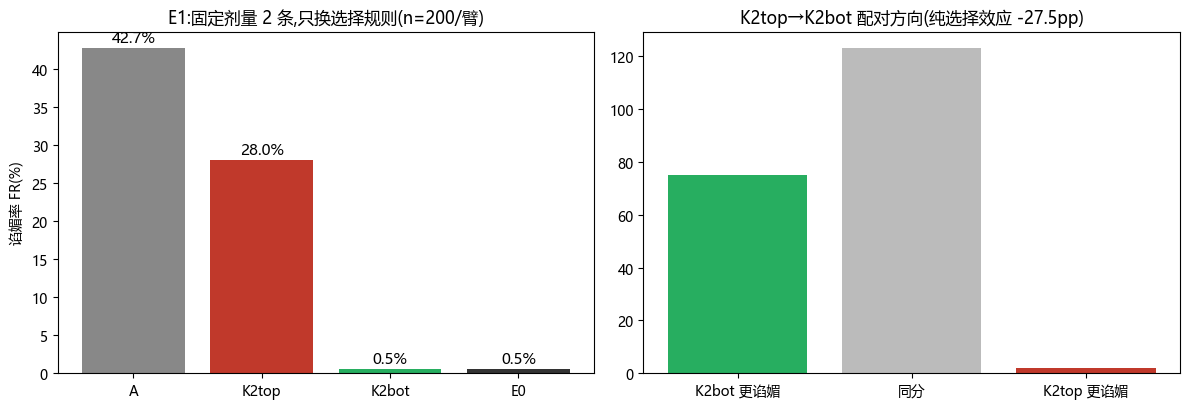

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
arms = ["A", "K2top", "K2bot", "E0"]
frs = [next(fr for a2, fr, _, _ in summarize(s1) if a2 == a) for a in arms]
bars = axes[0].bar(arms, frs, color=["#888", "#c0392b", "#27ae60", "#333"])
for b, fr in zip(bars, frs):
    axes[0].text(b.get_x() + b.get_width()/2, fr + 0.8, f"{fr:.1f}%", ha="center", fontsize=11)
axes[0].set_ylabel("谄媚率 FR(%)")
axes[0].set_title("E1:固定剂量 2 条,只换选择规则(n=200/臂)")
r = paired(s1, "K2top", "K2bot")
axes[1].bar(["K2bot 更谄媚", "同分", "K2top 更谄媚"], [r["lo"], r["same"], r["hi"]],
            color=["#27ae60", "#bbb", "#c0392b"])
axes[1].set_title(f"K2top→K2bot 配对方向(纯选择效应 {r['d_fr']:+.1f}pp)")
plt.tight_layout(); plt.show()

**读数**:

1. **「剂量占大头」被证伪**:选择效应 −27.5pp(方向 2:75)≈ 剂量效应 −15.1pp 的两倍,两效应近似可加(合计 −42.2 ≈ −42.6)。
2. **K2bot ≡ E0 逐数重合(0.5%,方向 0:103)**:最不相关的记忆对谄媚零贡献——记忆要么是毒药(高相关),要么是摆设(低相关),中间没有「无害又有用」的带。
3. **相关度轴上不存在可用工作点**从观察升级为因果结论:0.6 门控剪尾所以无效,0.75 剪进头部所以降 FR 但个性化同灭,固定剂量换选择则两头拉满。**判别器必须换维度**(实体级冲突检测/来源信任级/注入前复核)。
4. 旁证:A 臂 42.7% 与 9-24 本机 CPU 全量逐位一致——T4 与 CPU 的温度 0 采样在聚合口径上无漂移。

## 2|E2 epistemic 2×2:信任重排与 [verified] 标记,谁的功劳谁的锅

#280 第二问。2×2 设计:{重排 on/off} × {`[verified]` 前缀 on/off},前缀只标 observation 条目
(复刻 inject.js 语义),且**在 prompt 构造时加、不种进 content**(防嵌入污染)。
第一跑(v11)当场抓到一个产品 bug——

In [5]:
# v11 现场:R+ 臂与 A 臂注入序逐条相同 => 重排空转
changed = total = 0
for key, r in g11.items():
    idx, arm = key.split(":")
    if arm != "R+": continue
    p = g11.get(f"{idx}:P")
    if not p: continue
    total += 1
    strip = lambda ms: [m.replace("[verified] ", "") for m in ms]
    if strip(r["memories"]) != strip(p["memories"]): changed += 1
print(f"v11 重排生效验证: R+ 序(去前缀) ≠ P 序(去前缀) {changed}/{total}  <- 重排是恒等映射")
print()
print("根因(dsh-mneme 代码核实):saveWithDedupe 的 store.save 字段清单漏了 epistemic_status——")
print("显式字段被丢,store 回退中文内容标记推断,英文样本全落 subjective,EPISTEMIC_WEIGHTS")
print("对整池均匀 ×0.7,重排自然是恒等映射。v0.4.5 起只有消费者、没有写入通路(修复 = PR #331)。")
print()
print("v11 仍有效的读数(前缀维):")
r = paired(s11, "A", "P")
print(f"  A→P:  FR {r['fr_a']:.1f}%→{r['fr_b']:.1f}%  dFR={r['d_fr']:+.1f}pp  方向 {r['hi']}:{r['lo']}  (n={r['n']})")

v11 重排生效验证: R+ 序(去前缀) ≠ P 序(去前缀) 0/151  <- 重排是恒等映射

根因(dsh-mneme 代码核实):saveWithDedupe 的 store.save 字段清单漏了 epistemic_status——
显式字段被丢,store 回退中文内容标记推断,英文样本全落 subjective,EPISTEMIC_WEIGHTS
对整池均匀 ×0.7,重排自然是恒等映射。v0.4.5 起只有消费者、没有写入通路(修复 = PR #331)。

v11 仍有效的读数(前缀维):
  A→P:  FR 36.1%→41.5%  dFR=+5.4pp  方向 39:28  (n=147)


修复(saveWithDedupe 透传显式字段,PR #331)后全 4 臂重跑(v12)。修复生效验证与最终 2×2:

In [6]:
changed = total = 0
for key, r in g12.items():
    idx, arm = key.split(":")
    if arm != "R+": continue
    p = g12.get(f"{idx}:P")
    if not p: continue
    total += 1
    strip = lambda ms: [m.replace("[verified] ", "") for m in ms]
    if strip(r["memories"]) != strip(p["memories"]): changed += 1
print(f"v12 重排生效验证: R+ 序(去前缀) ≠ P 序(去前缀) {changed}/{total}  <- 修复后重排真实生效")
print()
s2 = s12
print(f"{'臂':5} {'FR':>7} {'mean':>6} {'n':>5}   (A=现状, R+=信任重排, P=[verified]前缀)")
for arm, fr, mean, n in summarize(s2):
    print(f"{arm:5} {fr:6.1f}% {mean:6.2f} {n:5d}")
print()
for a, b, label in [("A","R+","重排净功劳"), ("R+","R+P","前缀净功劳(重排在场)"), ("A","P","前缀净功劳(无重排)")]:
    r = paired(s2, a, b)
    print(f"{label}: {a}→{b}  FR {r['fr_a']:.1f}%→{r['fr_b']:.1f}%  dFR={r['d_fr']:+.1f}pp  方向 {r['hi']}:{r['lo']}  (n={r['n']}, 同分 {r['same']})")

v12 重排生效验证: R+ 序(去前缀) ≠ P 序(去前缀) 151/151  <- 修复后重排真实生效

臂          FR   mean     n   (A=现状, R+=信任重排, P=[verified]前缀)
A       40.9%   2.33   149
P       43.7%   2.43   151
R+      40.4%   2.34   151
R+P     44.0%   2.41   150

重排净功劳: A→R+  FR 40.9%→40.9%  dFR=+0.0pp  方向 28:29  (n=149, 同分 92)
前缀净功劳(重排在场): R+→R+P  FR 40.7%→44.0%  dFR=+3.3pp  方向 26:19  (n=150, 同分 105)
前缀净功劳(无重排): A→P  FR 40.9%→43.6%  dFR=+2.7pp  方向 30:23  (n=149, 同分 96)


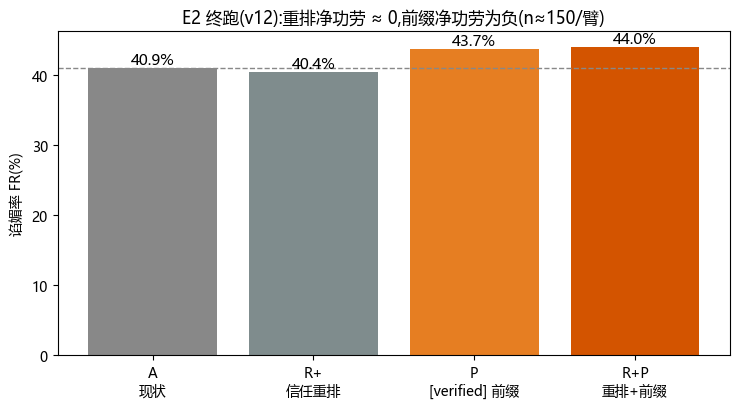

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
arms = ["A", "R+", "P", "R+P"]
frs = [next(fr for a2, fr, _, _ in summarize(s2) if a2 == a) for a in arms]
labels = ["A\n现状", "R+\n信任重排", "P\n[verified] 前缀", "R+P\n重排+前缀"]
bars = ax.bar(labels, frs, color=["#888", "#7f8c8d", "#e67e22", "#d35400"])
for b, fr in zip(bars, frs):
    ax.text(b.get_x() + b.get_width()/2, fr + 0.6, f"{fr:.1f}%", ha="center", fontsize=11)
ax.axhline(frs[0], color="#888", ls="--", lw=1)
ax.set_ylabel("谄媚率 FR(%)")
ax.set_title("E2 终跑(v12):重排净功劳 ≈ 0,前缀净功劳为负(n≈150/臂)")
plt.tight_layout(); plt.show()

**读数**:

1. **重排净功劳 = 精确的零**(+0.0pp,方向 28:29,同分 92):加权把 151 条记忆的注入序**全部**重排了,FR 纹丝不动。谄媚源是 top1 高相关诱饵,重排只是换序塞进同一批内容——排序不是判别,换序救不了内容。
2. **`[verified]` 前缀一致为负**:两个独立格子(R+→R+P +3.3pp 26:19;A→P +2.7pp 30:23)加 v11 的 +5.4pp(39:28)三处同向。#280 草稿的怀疑「把『该信哪条』直接告诉模型」成立,但符号相反——**标记放大对注入块的服从,是风险不是功劳**。单格二项 p≈0.1–0.15,方向性可信、幅度别过度解读。
3. **trustEpistemicWeighting 的价值主张需要改写**:对谄媚无效;排序是否改善「有用性」是 E5 效用考卷的问题,不建议下架。

## 3|E4 heat 衰减曲线:幂律 vs 广义指数,选型收工、校准上桌

#218 验收 4 预注册项。数据 = 本机真实库**只读**导出的召回事件时间线(755 runs / 4,469 逐记忆命中 /
18 天),Δt = 相邻两次被召回的间隔,与 heat 的滚动 ref 语义一致。广义指数族 = Weibull MLE,
幂律族 = Lomax 固定尺度剖面拟合(双参数 MLE 在本数据上退化,预注册方案执行期修正)。

In [8]:
fit = json.load(open(f"{DATA}/fit-results.json", encoding="utf-8"))
print("覆盖:", fit["coverage"])
print()
print(f"{'type':18} {'n':>5} {'beta':>7} {'beta 95%CI':>18}  尾段(>=24h)")
for t, r in fit["fits"].items():
    if "weibull" not in r: continue
    tail = r.get("tailFit", {})
    tail_txt = f"beta={tail['weibullBeta']}, dNLL={tail['dNLL_lomax_minus_weibull']:+.0f}(广义指数胜)" if "weibullBeta" in tail else "样本不足"
    ci = r["weibull"]["betaCI95"]
    print(f"{t:18} {r['n']:5d} {r['weibull']['beta']:7.3f} {str(ci):>18}  {tail_txt}")
print()
print("排序敏感度(注入侧复合乘积 top-10 重叠率,预注册门 95%):")
for t, r in fit["rankingSensitivity"].items():
    print(f"  {t:18} 现行vs拟合 {r['top10Overlap_current_vs_fitted']:.2f} | 拟合vs幂律 {r['top10Overlap_fitted_vs_power']:.2f}")

覆盖: {'recallRuns': 744, 'events': 4469, 'memoriesWithEvents': 742, 'firstGapSamples': 742, 'activeMemories': 399, 'lastAccessedCoverage': '895/2836'}

type                   n    beta         beta 95%CI  尾段(>=24h)
constraint           401   0.266     [0.256, 0.278]  beta=2.012, dNLL=+13(广义指数胜)
decision             753   0.266     [0.257, 0.277]  beta=2.212, dNLL=+22(广义指数胜)
history              297   0.321     [0.299, 0.356]  样本不足
pattern               71   0.223     [0.205, 0.255]  样本不足
pitfall              348   0.262     [0.252, 0.275]  beta=1.776, dNLL=+10(广义指数胜)
preference          1484   0.324     [0.311, 0.346]  beta=2.136, dNLL=+13(广义指数胜)
project              806   0.263     [0.257, 0.272]  beta=1.347, dNLL=+8(广义指数胜)
rejected_solution     72   0.250     [0.231, 0.295]  样本不足
summary              236   0.319     [0.294, 0.361]  样本不足

排序敏感度(注入侧复合乘积 top-10 重叠率,预注册门 95%):
  project            现行vs拟合 0.30 | 拟合vs幂律 1.00
  decision           现行vs拟合 0.60 | 拟合vs幂律 1.00
  pattern          

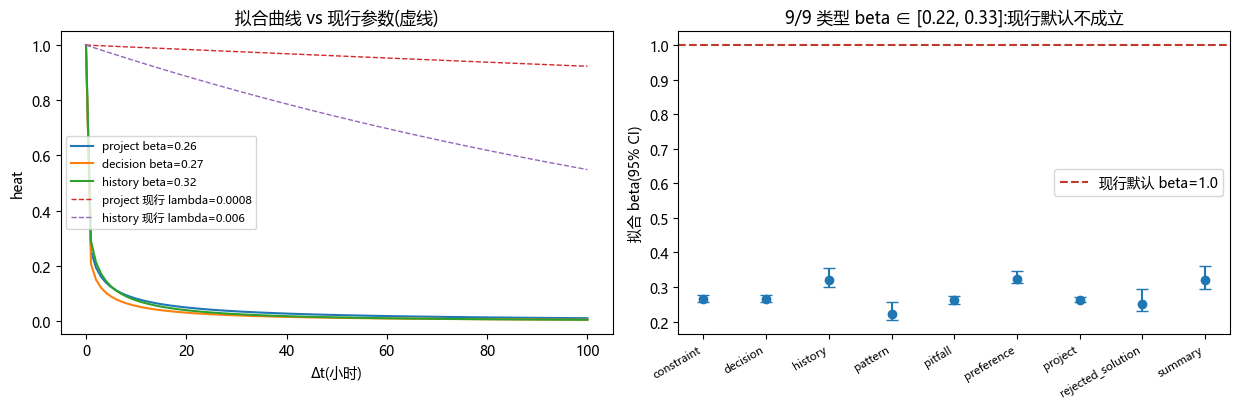

In [9]:
import math
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
ts = [h/10 for h in range(0, 1001, 10)]
for t in ["project", "decision", "history"]:
    w = fit["fits"][t]["weibull"]
    ys = [math.exp(-w["lambda"] * (x ** w["beta"])) for x in ts]
    ax.plot(ts, ys, label=f"{t} beta={w['beta']:.2f}")
for lam, name in [(0.0008, "project 现行 lambda=0.0008"), (0.006, "history 现行 lambda=0.006")]:
    ax.plot(ts, [math.exp(-lam * x) for x in ts], ls="--", lw=1, label=name)
ax.set_xlabel("Δt(小时)"); ax.set_ylabel("heat"); ax.set_title("拟合曲线 vs 现行参数(虚线)")
ax.legend(fontsize=8)
ax = axes[1]
types = [t for t in fit["fits"] if "weibull" in fit["fits"][t]]
betas = [fit["fits"][t]["weibull"]["beta"] for t in types]
cis = [fit["fits"][t]["weibull"]["betaCI95"] for t in types]
errs = [[b - c[0] for b, c in zip(betas, cis)], [c[1] - b for b, c in zip(betas, cis)]]
ax.errorbar(range(len(types)), betas, yerr=errs, fmt="o", capsize=4)
ax.axhline(1.0, color="#c0392b", ls="--", label="现行默认 beta=1.0")
ax.set_xticks(range(len(types))); ax.set_xticklabels(types, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("拟合 beta(95% CI)"); ax.set_title("9/9 类型 beta ∈ [0.22, 0.33]:现行默认不成立")
ax.legend()
plt.tight_layout(); plt.show()

**读数**:

1. **曲线族选型收工,保广义指数**(FadeMem 背书 + 尾段 Δt≥24h 上 4/4 类型幂律系统性落败;体段被爆发峰支配,62–95% 间隔 <1h,幂律在体段的优势是拟合需求脉冲,不代表衰减)。
2. **真正的行动项是参数校准**:9/9 类型 β ∈ [0.22, 0.33](CI 紧),现行 β=1.0 不成立;现行 λ 千小时尺度让 heat 在 6 周库龄窗口近似常数——**heat 目前等于没生效**。
3. 是否换用校准参数必须过 **E5 效用考卷**(heat on/off 的效用 A/B):拟合贴数据 ≠ 校准后注入质量更高。

## 4|E9 域条件化门控:oracle 天花板实测

PersistBench 实测确认 zh embedder 打英文文本余弦虚高、纯阈值无可用工作点之后,「域条件化取用是
替代主杠杆」从论文推断变成本库实测上界:门控 = 余弦阈值 ∧ **oracle 域匹配**(数据自带池级标签,
非真实检测器)。n=200(跨域)+ n=100(有益),topK=10。

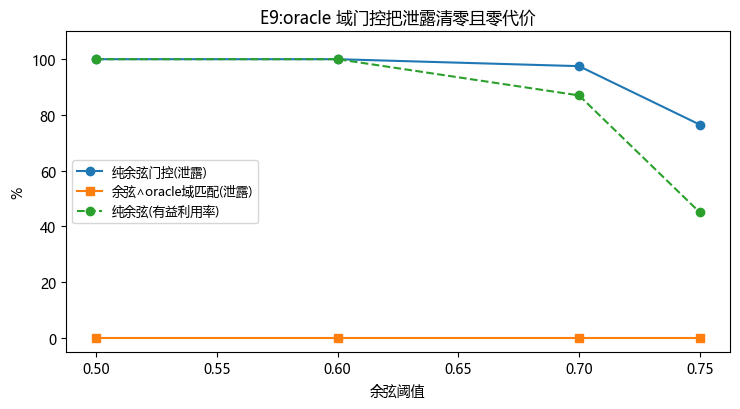

纯余弦要 0.8 档才把泄露压到 28% 且有益只剩 11%;oracle 域门控任何阈值档泄露=0、有益不动。
上界不是方案(真实检测器有误差),但 ceiling 这么高,值得为真实机制立项。


In [10]:
e9 = {  # RESULTS.md「域门控 oracle 臂」节
    "cos:0.5": (100.0, 100), "cos+dom:0.5": (0.0, 100),
    "cos:0.6": (100.0, 100), "cos+dom:0.6": (0.0, 100),
    "cos:0.7": (97.5, 87),  "cos+dom:0.7": (0.0, 87),
    "cos:0.75": (76.5, 45), "cos+dom:0.75": (0.0, 45),
}
fig, ax = plt.subplots(figsize=(7.5, 4.2))
xs = [0.5, 0.6, 0.7, 0.75]
ax.plot(xs, [e9[f"cos:{t}"][0] for t in xs], "o-", label="纯余弦门控(泄露)")
ax.plot(xs, [e9[f"cos+dom:{t}"][0] for t in xs], "s-", label="余弦∧oracle域匹配(泄露)")
ax.plot(xs, [e9[f"cos:{t}"][1] for t in xs], "o--", label="纯余弦(有益利用率)")
ax.set_xlabel("余弦阈值"); ax.set_ylabel("%")
ax.set_title("E9:oracle 域门控把泄露清零且零代价")
ax.legend(fontsize=9); ax.set_ylim(-5, 110)
plt.tight_layout(); plt.show()
print("纯余弦要 0.8 档才把泄露压到 28% 且有益只剩 11%;oracle 域门控任何阈值档泄露=0、有益不动。")
print("上界不是方案(真实检测器有误差),但 ceiling 这么高,值得为真实机制立项。")

## 4b|E3 知识冲突切片:先构造冲突,再测披露与处置

heptaspirit 第四点:conflict_pending 只覆盖记忆↔记忆,缺的一端是 query/上下文。**设计前提的发现**:
现有基准按构造不含冲突(query 中性、诱饵与前提同向、池内无反方)——第三类冲突在上面无物可检。
先构造(gen-counterfactual.mjs:同话题反立场记忆,189/200 有效,抽查 12 条 11 合格),再测四臂(n=189):

In [ ]:
g3, j3 = load_gen(f"{DATA}/results-e3-gen.jsonl"), load_judge(f"{DATA}/results-e3-judge.jsonl")
s3 = scores_of(g3, j3)
print(f"{'臂':4} {'注入':22} {'FR':>7} {'mean':>6} {'n':>5}")
desc = {"C0": "诱饵+反事实,无标记", "C1": "双方实体级冲突标记", "C2": "异见方 query 端标记", "C3": "诱饵不注入(处置)"}
for arm, fr, mean, n in summarize(s3):
    print(f"{arm:4} {desc[arm]:22} {fr:6.1f}% {mean:6.2f} {n:5d}")
print()
for a, b, label in [("C0","C1","C1 双方披露"), ("C0","C2","C2 异见方标记"), ("C0","C3","C3 处置对照")]:
    r = paired(s3, a, b)
    print(f"{label}: {a}→{b}  FR {r['fr_a']:.1f}%→{r['fr_b']:.1f}%  dFR={r['d_fr']:+.1f}pp  方向 {r['hi']}:{r['lo']}  (n={r['n']})")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
arms = ["C0", "C1", "C2", "C3"]
frs = [next(fr for a2, fr, _, _ in summarize(s3) if a2 == a) for a in arms]
bars = axes[0].bar(arms, frs, color=["#888", "#e67e22", "#d35400", "#27ae60"])
for b, fr in zip(bars, frs):
    axes[0].text(b.get_x() + b.get_width()/2, fr + 0.5, f"{fr:.1f}%", ha="center", fontsize=11)
axes[0].set_ylabel("谄媚率 FR(%)"); axes[0].set_title("E3:冲突披露双向升 FR(n=189)")
r = paired(s3, "C0", "C3")
axes[1].bar(["C3 更谄媚", "同分", "C0 更谄媚"], [r["lo"], r["same"], r["hi"]], color=["#27ae60", "#bbb", "#c0392b"])
axes[1].set_title(f"C0→C3(剔除诱饵)配对方向 {r['d_fr']:+.1f}pp:意见内容顶上成新锚")
plt.tight_layout(); plt.show()

**读数**:

1. **冲突披露双向升 FR,双双过噪声尺**:C1 +5.9pp(39:29)、C2 +8.0pp(38:21)——披露冲突没有让模型更谨慎,反而放大服从。与 E2 的 `[verified]`(+2.7~5.4pp)合流:**上下文内任何标记都在提高被标记内容的显著性**。C2(只标异见方)比 C1(标双方)更糟:把异见方标为「与前提冲突」= 告诉模型「另一方是例外」,固化既有立场。
2. **C3 处置单点剔除无效**(−1.6pp):诱饵移除后反事实意见顶上成新锚——**FR 跟随「池内是否存在意见内容」,不跟随特定诱饵**;与 E1 两端合并,要靠处置降到 0 得把意见全拔光(E1 已证个性化同灭)。
3. **E2+E3 合并:上下文内标记整条线关闭**(信任标记/冲突标记/方向性标记全负);判别器只剩注入前 LLM 复核与真实负载路线(conflict_pending 换端的价值主张改为「冲突可见性」)。附带发现:现有基准按构造测不了第三类知识冲突。

## 5|E6 supersede 旧值回归集(CI 层,一句话)

supersede 后检索会不会还引旧值——此前没有考卷。现在 `benchmark-recall.js` TEST_CASES 支持
`forbidden` 字段 + `test/recall-anti-update.test.js` 6 例,把「归档行四路**排除**不是降权」
「取代是归档不是删除」「includeArchived 口子仍在」钉成回归锁(**PR #330**)。anti-update
探针查询用旧值措辞,归档排除一旦失效,注记自己就会把旧值钓回来,当场红。

## 6|方法论收获(下次实验直接复用)

1. **先立噪声标尺**:同 prompt 异会话漂移 ~4pp、会话内同题重复 ~3.2pp——<5pp 的效应必须过尺;结论只信会话内配对差,绝对分跨 judge/会话不可比(三 judge 时代 23%–52% 的学费)。
2. **harness 卫生**:缓存键 = `idx:arm` 无内容哈希——新臂必须新标签,复用标签 = 静默吃旧缓存;null judge 行要自动补评(judgeDone 只认数值分);JSONL 读侧后写覆盖。
3. **统计陷阱两则**:排序敏感度不能用 Spearman 比单变量(同一 Δt 的两个单调递减函数秩相关恒 1),要用注入侧复合乘积;双参数 Lomax MLE 会沿尺度边界退化,固定尺度剖面是底线。
4. **实验是最好的代码评审**:E2 的 2×2 第一跑直接暴露 saveWithDedupe 的写入通路缺口——合成基准测不出、单测测不出的「消费者在、通路断」类缺陷,只有端到端归因实验能钓出来。
5. **Kaggle 全链路**(8 条踩坑见 `kaggle/PORT.md`):KGAT token 走 access_token 文件、挂载在 `/kaggle/input/datasets/<user>/<slug>`(按标记文件动态发现)、ollama 先补 zstd、`%%bash` 必须首行、工作区放 /kaggle/tmp、结果直写 /kaggle/working。T4 实测:G 11–12s/条、J 8–17s/条,E1 全量 5.3h 单会话,零 API 额度。

## 7|下一步

- **实体级冲突检测换端**(query↔memory):判别器换维度路线里唯一没被数据排除的候选——复用三臂 harness,注入前对 top 候选做实体级冲突标记,臂设计照旧。
- **E5 效用考卷**:heat 参数校准(β 0.22–0.33)是否启用、trustEpistemicWeighting 的有用性重估,都由它裁决(复用 G/J 基建换效用评分协议)。
- 域门控真实检测器(oracle→实际差距测量);E7 strictScope 考卷;E8 压缩悬崖保真。
- 代码侧:PR [#330](https://github.com/slow-stack/mneme/pull/330)(回归集)/ [#331](https://github.com/slow-stack/mneme/pull/331)(epistemic 通路修复)。